# 09 - Severity Scoring

**Purpose:** Convert model outputs into a quality severity decision.

**Expected output:** Formula, component examples, severity levels, pass/fail decisions, and backend-ready dictionaries.

**Platform connection:** This explains how AI predictions become QA actions.


In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())

from ml.severity import calculate_severity_from_prediction


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## Severity Formula


In [2]:
display(pd.DataFrame([
    {"component": "defect size", "weight": "30%", "source": "defect area ratio / mask area"},
    {"component": "defect location", "weight": "25%", "source": "critical region heuristic"},
    {"component": "defect type", "weight": "25%", "source": "classifier category seriousness"},
    {"component": "detection confidence", "weight": "20%", "source": "model confidence"},
]))
display(Markdown("**Severity Score = Size x 30% + Location x 25% + Type x 25% + Confidence x 20%**"))


,component,weight,source
0,defect size,30%,defect area ratio / mask area
1,defect location,25%,critical region heuristic
2,defect type,25%,classifier category seriousness
3,detection confidence,20%,model confidence


**Severity Score = Size x 30% + Location x 25% + Type x 25% + Confidence x 20%**

## Severity Examples


,case,defect_type,confidence,area_ratio,severity_score,severity_level,pass_fail,recommended_action
0,minor cosmetic mark,scratch,0.62,0.002,35.90,Low,Pass,Product generally acceptable
1,contamination near center,contamination,0.86,0.018,66.95,High,Fail,Repair or rework recommended
2,small break,broken_small,0.91,0.035,80.45,Critical,Fail,Reject product and trigger quality inspection ...
3,large break,broken_large,0.97,0.080,92.65,Critical,Fail,Reject product and trigger quality inspection ...


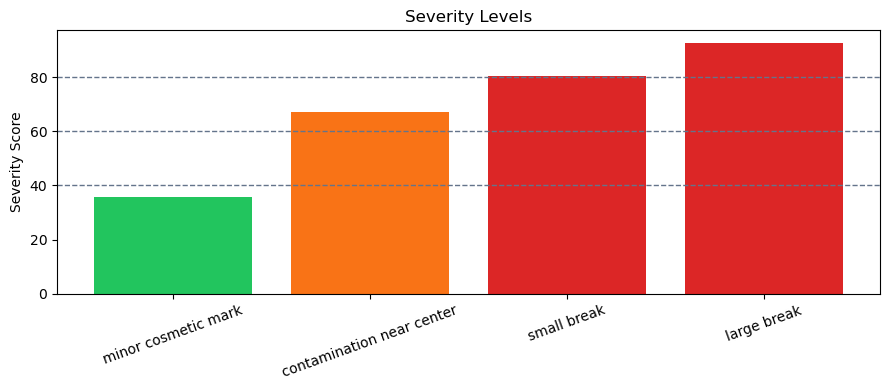

In [3]:
examples = [
    {"case": "minor cosmetic mark", "defect_type": "scratch", "confidence": 0.62, "area_ratio": 0.002, "critical": False, "center_y": 0.15},
    {"case": "contamination near center", "defect_type": "contamination", "confidence": 0.86, "area_ratio": 0.018, "critical": True, "center_y": 0.50},
    {"case": "small break", "defect_type": "broken_small", "confidence": 0.91, "area_ratio": 0.035, "critical": True, "center_y": 0.55},
    {"case": "large break", "defect_type": "broken_large", "confidence": 0.97, "area_ratio": 0.080, "critical": True, "center_y": 0.48},
]
rows = []
for item in examples:
    result = calculate_severity_from_prediction(item["defect_type"], item["confidence"], item["area_ratio"], item["critical"], item["center_y"])
    rows.append({"case": item["case"], "defect_type": item["defect_type"], "confidence": item["confidence"], "area_ratio": item["area_ratio"], "severity_score": result["severity_score"], "severity_level": result["severity_level"], "pass_fail": result["pass_fail"], "recommended_action": result["recommended_action"]})
severity_df = pd.DataFrame(rows)
display(severity_df)
fig, ax = plt.subplots(figsize=(9, 4))
colors = severity_df["severity_level"].map({"Low": "#22c55e", "Medium": "#eab308", "High": "#f97316", "Critical": "#dc2626"})
ax.bar(severity_df["case"], severity_df["severity_score"], color=colors)
for y in [40, 60, 80]:
    ax.axhline(y, color="#64748b", linestyle="--", linewidth=1)
ax.set_ylabel("Severity Score")
ax.set_title("Severity Levels")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Component Breakdown And Backend Shape


,component,score
0,size_score,90.0
1,location_score,90.0
2,defect_type_score,95.0
3,confidence_score,97.0


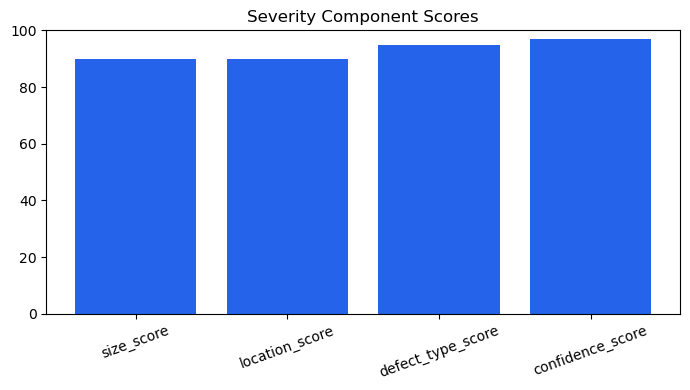

{
  "defect_type": "broken_large",
  "confidence": 0.97,
  "area_ratio": 0.08,
  "severity_score": 92.65,
  "severity_level": "Critical",
  "pass_fail": "Fail",
  "recommended_action": "Reject product and trigger quality inspection workflow",
  "components": {
    "size_score": 90.0,
    "location_score": 90.0,
    "defect_type_score": 95.0,
    "confidence_score": 97.0
  }
}


In [4]:
selected = calculate_severity_from_prediction("broken_large", 0.97, 0.080, True, 0.48)
component_df = pd.DataFrame([{"component": k, "score": v} for k, v in selected["components"].items()])
display(component_df)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(component_df["component"], component_df["score"], color="#2563eb")
ax.set_ylim(0, 100)
ax.set_title("Severity Component Scores")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
backend_ready = {
    "defect_type": selected["defect_type"],
    "confidence": selected["confidence"],
    "area_ratio": selected["area_ratio"],
    "severity_score": selected["severity_score"],
    "severity_level": selected["severity_level"],
    "pass_fail": selected["pass_fail"],
    "recommended_action": selected["recommended_action"],
    "components": selected["components"],
}
print(json.dumps(backend_ready, indent=2))


## Business Decision Mapping

Severity is not only a number. It decides what the quality team should do next.


In [5]:
decision_mapping_df = pd.DataFrame([
    {"AI output": "Good", "severity range": "0", "business meaning": "product can pass", "recommended workflow": "release product"},
    {"AI output": "Defective + Low", "severity range": "0-39", "business meaning": "minor cosmetic concern", "recommended workflow": "accept or optional review"},
    {"AI output": "Defective + Medium", "severity range": "40-59", "business meaning": "quality concern", "recommended workflow": "manual review"},
    {"AI output": "Defective + High", "severity range": "60-79", "business meaning": "significant defect", "recommended workflow": "send to rework"},
    {"AI output": "Defective + Critical", "severity range": "80-100", "business meaning": "major quality/safety risk", "recommended workflow": "reject or urgent QA action"},
])
display(decision_mapping_df)


,AI output,severity range,business meaning,recommended workflow
0,Good,0,product can pass,release product
1,Defective + Low,0-39,minor cosmetic concern,accept or optional review
2,Defective + Medium,40-59,quality concern,manual review
3,Defective + High,60-79,significant defect,send to rework
4,Defective + Critical,80-100,major quality/safety risk,reject or urgent QA action


## Confidence Interpretation

Confidence is used as a reliability signal. A high-confidence defect can be handled automatically, while a low-confidence prediction can be sent for manual review even if the model detects an anomaly.


## Severity Policy Simulation

This shows how a batch of inspection outputs would be distributed across Pass, Review, Rework, and Reject decisions.


,case,defect_type,severity_score,severity_level,policy_action
0,minor cosmetic mark,scratch,35.90,Low,Pass
1,contamination near center,contamination,66.95,High,Send To Rework
2,small break,broken_small,80.45,Critical,Reject / Urgent QA
3,large break,broken_large,92.65,Critical,Reject / Urgent QA


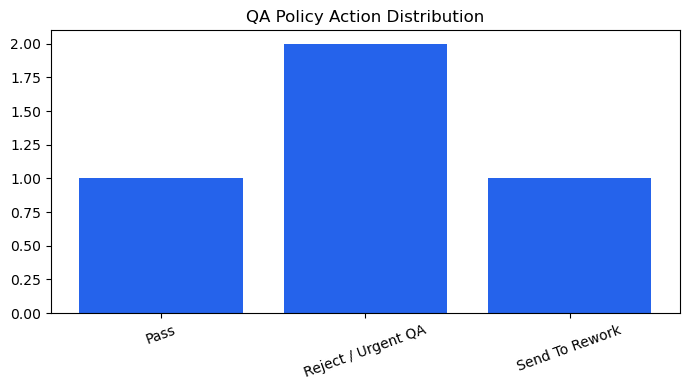

In [6]:
policy_df = severity_df.copy()
policy_df["policy_action"] = policy_df["severity_level"].map({
    "Low": "Pass",
    "Medium": "Manual Review",
    "High": "Send To Rework",
    "Critical": "Reject / Urgent QA",
})
display(policy_df[["case", "defect_type", "severity_score", "severity_level", "policy_action"]])

policy_counts = policy_df.groupby("policy_action").size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(policy_counts["policy_action"], policy_counts["count"], color="#2563eb")
ax.set_title("QA Policy Action Distribution")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Validation Outcome

- The project converts AI output into QA decisions.
- Severity scoring is explainable and component-based.
- The output shape can be sent to the backend/frontend inspection result page.
